# EDA — Résultats des élections municipales (2008–2020)
## Focus : hétérogénéité statistique des communes de moins de 1 000 habitants

**Contexte électoral (rappel indispensable avant toute analyse statistique)**

En France, le mode de scrutin pour les élections municipales dépend de la taille de la commune :

| Taille commune | Mode de scrutin | Conséquence sur les données |
|---|---|---|
| **< 1 000 habitants** | Scrutin **plurinominal majoritaire** à 2 tours, **avec panachage** (art. L252 et s. du code électoral) | Chaque électeur vote pour **autant de candidats que de sièges à pourvoir** (souvent 7 à 15). Un candidat = une ligne, mais `Voix` compte des suffrages individuels. **`somme(Voix) ≠ Exprimés`** : la somme des voix par bureau est en réalité un multiple d'`Exprimés` (≈ nombre de sièges), pas égale à `Exprimés`. |
| **≥ 1 000 habitants** | Scrutin de **liste** à la proportionnelle, 2 tours | Chaque électeur vote pour **une seule liste**. `somme(Voix par liste) = Exprimés`. Les statistiques usuelles (taux par rapport aux exprimés) sont directement interprétables. |

**Pourquoi vos stats "ne sont plus homogènes" sous les 1 000 habitants :**

1. Le ratio `somme(Voix) / Exprimés` n'est plus ≈ 1 mais variable et dépendant du **nombre de sièges à pourvoir**, qui lui-même dépend de la strate de population (la loi fixe un barème de sièges par tranche de population).
2. Toute statistique calculée *par candidat* en divisant par `Exprimés` (ex. `pct_voix_exprimes`) devient **non comparable** entre une commune de 200 habitants (9 sièges) et une commune de 950 habitants (15 sièges), ni avec les communes ≥1000 hab (1 voix = 1 électeur).
3. Mélanger les deux régimes dans un même calcul agrégé (comme fait dans le notebook 2 avec un facteur correctif uniforme) **introduit du bruit** au lieu de le corriger, car ça traite comme une "anomalie de saisie" ce qui est en réalité un effet de structure légale.

**Objectif de ce notebook :**
- Fusionner les deux notebooks sources (chargement + enrichissement géographique + EDA)
- **Séparer proprement** scrutin majoritaire (<1000 hab) et scrutin de liste (≥1000 hab)
- Distinguer les vraies anomalies de saisie des effets structurels du panachage
- Produire une EDA comparative qui rend les deux populations à nouveau homogènes *au sein de chaque strate*


## 1. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style="whitegrid")

from src.preprocessing import load_and_clean_processed_res

In [28]:
# Source "détail candidats / voix" (notebook 2)
df = load_and_clean_processed_res()
print(df.shape)
df.head()

(1709395, 14)


,Annee,Tour,Code département,Code commune,Libellé commune,Code BV,Inscrits,Votants,Abstentions,Exprimés,Code Nuance,Voix,Nuance,Libellé
0,2008,1,ZA,101,Les Abymes,0001,540,362,178,348,LSOC,22.0,LSOC,Liste du Parti socialiste
1,2008,1,ZA,101,Les Abymes,0001,540,362,178,348,LDVG,144.0,LDVG,Liste divers gauche
2,2008,1,ZA,101,Les Abymes,0001,540,362,178,348,LDVG,182.0,LDVG,Liste divers gauche
3,2008,1,ZA,101,Les Abymes,0002,273,175,98,156,LSOC,12.0,LSOC,Liste du Parti socialiste
4,2008,1,ZA,101,Les Abymes,0002,273,175,98,156,LDVG,86.0,LDVG,Liste divers gauche


### 1.1 Première inspection

On vérifie d'abord que les deux sources partagent bien les mêmes clés de jointure
(`Annee`, `Tour`, `Code département`, `Code commune`) avant de fusionner quoi que ce soit.


In [29]:
print("=== df (résultats détaillés) ===")
df.info()

=== df (résultats détaillés) ===
<class 'pandas.DataFrame'>
RangeIndex: 1709395 entries, 0 to 1709394
Data columns (total 14 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Annee             int64  
 1   Tour              int64  
 2   Code département  str    
 3   Code commune      str    
 4   Libellé commune   str    
 5   Code BV           str    
 6   Inscrits          int64  
 7   Votants           int64  
 8   Abstentions       int64  
 9   Exprimés          int64  
 10  Code Nuance       str    
 11  Voix              float64
 12  Nuance            str    
 13  Libellé           str    
dtypes: float64(1), int64(6), str(7)
memory usage: 182.6 MB


## 3. Enrichissement géographique (API geo.gouv.fr)

**Ce point est critique pour votre problème** : on a besoin de la **population réelle**
de chaque commune pour appliquer le bon seuil (1 000 habitants), pas seulement du
nombre d'`Inscrits` (qui n'est pas équivalent — un électeur inscrit ≠ un habitant,
et le seuil légal est basé sur la population municipale INSEE, pas sur les inscrits).


In [30]:
def build_code_insee(row):
    dep = str(row['Code département']).strip().zfill(2)
    com = str(row['Code commune']).strip().zfill(3)
    return dep + com

df['code_insee'] = df.apply(build_code_insee, axis=1)
df = df[df["Code département"].isin([f"{i:02d}" for i in range(1,100)])] # Pour enlever les outre mer
df_communes = df[['code_insee']].drop_duplicates().copy()
print(f"{len(df_communes)} communes uniques à interroger")

70500 communes uniques à interroger


In [5]:
FIELDS = "nom,population,surface,centre,codesPostaux,codeEpci,codeRegion,codeDepartement"
BASE_URL = "https://geo.api.gouv.fr/communes"

def fetch_commune_geo(code_insee: str) -> dict | None:
    # Récupère population/surface/coordonnées d'une commune via son code INSEE.
    url = f"{BASE_URL}/{code_insee}"
    try:
        resp = requests.get(url, params={"fields": FIELDS}, timeout=5)
        if resp.status_code == 200:
            data = resp.json()
            lon, lat = None, None
            if "centre" in data and data["centre"]:
                lon, lat = data["centre"]["coordinates"]
            return {
                "code_insee": code_insee,
                "geo_nom": data.get("nom"),
                "population": data.get("population"),   # <-- clé pour notre seuil <1000 hab
                "surface_km2": data.get("surface"),
                "longitude": lon,
                "latitude": lat,
            }
    except Exception as e:
        print(f"Erreur pour {code_insee}: {e}")
    return None

In [6]:
results = []
codes = df_communes['code_insee'].tolist()
max_workers = min(16, (os.cpu_count() or 4) * 5)
max_workers = min(max_workers, len(codes)) if codes else 1
print(f"Récupération de {len(codes)} communes avec {max_workers} threads...")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_to_code = {executor.submit(fetch_commune_geo, code): code for code in codes}
    for i, future in enumerate(as_completed(future_to_code), 1):
        result = future.result()
        if result:
            results.append(result)
        if i % 500 == 0 or i == len(codes):
            print(f"{i}/{len(codes)} communes traitées...")

df_geo = pd.DataFrame(results)
print(f"Terminé : {len(df_geo)}/{len(codes)} communes récupérées")
df_geo.head()

Récupération de 70500 communes avec 16 threads...
500/70500 communes traitées...
1000/70500 communes traitées...
1500/70500 communes traitées...
2000/70500 communes traitées...
2500/70500 communes traitées...
3000/70500 communes traitées...
3500/70500 communes traitées...
4000/70500 communes traitées...
4500/70500 communes traitées...
5000/70500 communes traitées...
5500/70500 communes traitées...
6000/70500 communes traitées...
6500/70500 communes traitées...
7000/70500 communes traitées...
7500/70500 communes traitées...
8000/70500 communes traitées...
8500/70500 communes traitées...
9000/70500 communes traitées...
9500/70500 communes traitées...
10000/70500 communes traitées...
10500/70500 communes traitées...
11000/70500 communes traitées...
11500/70500 communes traitées...
12000/70500 communes traitées...
12500/70500 communes traitées...
13000/70500 communes traitées...
13500/70500 communes traitées...
14000/70500 communes traitées...
14500/70500 communes traitées...
15000/70500 c

,code_insee,geo_nom,population,surface_km2,longitude,latitude
0,01004,Ambérieu-en-Bugey,15934,2454.80,5.3706,45.9575
1,01014,Arbent,3555,2366.87,5.6879,46.2838
2,01053,Bourg-en-Bresse,42372,2403.23,5.2469,46.2027
3,01043,Beynost,5198,1068.97,4.9964,45.8359
4,01033,Valserhône,16712,6286.07,5.7944,46.1234


In [31]:
df = df.merge(df_geo, on='code_insee', how='left')

n_missing_pop = df['population'].isna().sum()
print(f"Lignes sans population récupérée : {n_missing_pop} ({n_missing_pop/len(df)*100:.2f} %)")

df['population'] = df['population'].fillna(df['Inscrits'])
df[['code_insee', 'Libellé commune', 'population']].drop_duplicates('code_insee').head()

Lignes sans population récupérée : 257126 (16.23 %)


,code_insee,Libellé commune,population
0,01004,Ambérieu-en-Bugey,15934.0
32,01014,Arbent,3555.0
36,01033,Bellegarde-sur-Valserine,16712.0
50,01034,Belley,9388.0
65,01043,Beynost,5198.0


## 4. Nettoyage général et reconstruction des bureaux de vote

On reprend les contrôles d'intégrité du notebook 2 (`Votants ≤ Inscrits`,
`Exprimés ≤ Votants`), en les appliquant **avant** le diagnostic du panachage,
car ces deux familles de problèmes sont de nature différente :

- `Votants > Inscrits` ou `Exprimés > Votants` → **erreurs de saisie/encodage** réelles, à corriger ou supprimer.
- `somme(Voix) > Exprimés` dans les communes <1000 hab → **effet structurel du panachage**, à traiter séparément (section 5), surtout pas avec le même "facteur correctif".


In [32]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum().sort_values(ascending=False).head(15))

Valeurs manquantes par colonne :
Nuance              894422
Libellé             894422
geo_nom             257126
surface_km2         257126
longitude           257126
latitude            257126
Tour                     0
Annee                    0
Code commune             0
Code département         0
Libellé commune          0
Code BV                  0
Voix                     0
Code Nuance              0
Exprimés                 0
dtype: int64


In [33]:
# 4.1 Identification du bureau de vote (granularité la plus fine disponible)
bv_keys_base = ['Annee', 'Tour', 'Code département', 'Code commune',
                'Inscrits', 'Votants', 'Abstentions', 'Exprimés']

bv_groups = df[bv_keys_base].drop_duplicates().copy()
bv_groups['ID Bureau de vote'] = (
    bv_groups
    .groupby(['Annee', 'Tour', 'Code département', 'Code commune'])
    .cumcount() + 1
)
df = df.merge(bv_groups, on=bv_keys_base, how='left')

bv_keys = ['Annee', 'Tour', 'Code département', 'Code commune', 'ID Bureau de vote']
print(f"Nombre de bureaux de vote uniques : {df.groupby(bv_keys).ngroups:,}")
df.head()

Nombre de bureaux de vote uniques : 274,083


,Annee,Tour,Code département,Code commune,Libellé commune,Code BV,Inscrits,Votants,Abstentions,Exprimés,Code Nuance,Voix,Nuance,Libellé,code_insee,geo_nom,population,surface_km2,longitude,latitude,ID Bureau de vote
0,2008,1,01,004,Ambérieu-en-Bugey,0001,1100,622,478,589,LUG,172.0,LUG,Liste Union de la Gauche,01004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1
1,2008,1,01,004,Ambérieu-en-Bugey,0001,1100,622,478,589,LGC,111.0,LGC,Liste gauche-centristes,01004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1
2,2008,1,01,004,Ambérieu-en-Bugey,0001,1100,622,478,589,LDVD,214.0,LDVD,Liste divers droite,01004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1
3,2008,1,01,004,Ambérieu-en-Bugey,0001,1100,622,478,589,LDVD,92.0,LDVD,Liste divers droite,01004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,1
4,2008,1,01,004,Ambérieu-en-Bugey,0002,935,497,438,477,LUG,148.0,LUG,Liste Union de la Gauche,01004,Ambérieu-en-Bugey,15934.0,2454.8,5.3706,45.9575,2


In [34]:
# 4.2 Anomalies de saisie classiques (hors panachage) — tolérance faible car ce sont
# des incohérences arithmétiques de base, pas un effet de scrutin.
tolerance = 5

mask_votants = df['Votants'] > df['Inscrits']
mask_exprimes = df['Exprimés'] > df['Votants']
print(f"Lignes Votants > Inscrits  : {mask_votants.sum():,}")
print(f"Lignes Exprimés > Votants  : {mask_exprimes.sum():,}")

# Cap si l'écart est faible (arrondi/erreur mineure), sinon suppression
small_diff = mask_votants & ((df['Votants'] - df['Inscrits']) <= tolerance)
df.loc[small_diff, 'Votants'] = df.loc[small_diff, 'Inscrits']
large_diff = df['Votants'] > df['Inscrits']
if large_diff.any():
    print(f"  -> {large_diff.sum():,} lignes supprimées (écart Votants > Inscrits trop grand)")
    df = df[~large_diff].copy()

mask_exprimes = df['Exprimés'] > df['Votants']
small_diff_exp = mask_exprimes & ((df['Exprimés'] - df['Votants']) <= tolerance)
df.loc[small_diff_exp, 'Exprimés'] = df.loc[small_diff_exp, 'Votants']
large_diff_exp = df['Exprimés'] > df['Votants']
if large_diff_exp.any():
    print(f"  -> {large_diff_exp.sum():,} lignes supprimées (écart Exprimés > Votants trop grand)")
    df = df[~large_diff_exp].copy()

assert (df['Votants'] <= df['Inscrits']).all()
assert (df['Exprimés'] <= df['Votants']).all()
print("\n✔ Contrôles d'intégrité Inscrits/Votants/Exprimés OK")

Lignes Votants > Inscrits  : 1
Lignes Exprimés > Votants  : 1
  -> 1 lignes supprimées (écart Exprimés > Votants trop grand)

✔ Contrôles d'intégrité Inscrits/Votants/Exprimés OK


In [35]:
# 4.3 Outliers grossiers sur Inscrits (déjà repéré dans le notebook 2 : valeurs > 1e5
# pour des petites communes = erreur de saisie). On corrige par la médiane observée
# pour cette commune sur d'autres années, au lieu d'une valeur en dur.
outliers_inscrits = df[df['Inscrits'] > 1e5]
print(f"{len(outliers_inscrits)} lignes avec Inscrits > 100 000")
display(outliers_inscrits[['Annee', 'Libellé commune', 'Inscrits']].drop_duplicates())

4 lignes avec Inscrits > 100 000


,Annee,Libellé commune,Inscrits
87637,2008,Châtenay-Malabry,966620


In [36]:
for commune in outliers_inscrits['Libellé commune'].unique():
    mediane = df.loc[
        (df['Libellé commune'] == commune) & (df['Inscrits'] <= 1e5),
        'Inscrits'
    ].median()
    if pd.notna(mediane):
        mask = (df['Libellé commune'] == commune) & (df['Inscrits'] > 1e5)
        df.loc[mask, 'Inscrits'] = int(mediane)
        print(f"{commune}: Inscrits corrigé -> {int(mediane)} ({mask.sum()} lignes)")

# Recalcul de cohérence après correction
df['Abstentions'] = df['Inscrits'] - df['Votants']
df['Vote Blanc'] = df['Votants'] - df['Exprimés']

Châtenay-Malabry: Inscrits corrigé -> 959 (4 lignes)


## 5. Diagnostic du panachage (communes < 1 000 habitants)

C'est ici qu'on traite **spécifiquement** votre problème. On calcule, par bureau de vote,
le ratio :

$$\text{ratio\_panachage} = \frac{\sum \text{Voix}}{\text{Exprimés}}$$

**Attendu théorique :**
- communes ≥ 1000 hab (scrutin de liste) → ratio ≈ **nombre de listes en présence** si on somme toutes les lignes candidat/liste confondues, mais ≈ **1** si on raisonne *par liste*. Il faut donc être précis sur le niveau d'agrégation (`Liste` vs `candidat`).
- communes < 1000 hab (panachage) → ratio ≈ **nombre de sièges à pourvoir** (souvent entre 7 et 15 selon strate de population), car chaque exprimé "distribue" ses voix sur plusieurs candidats.

On vérifie cette hypothèse empiriquement avant de l'utiliser comme correction.


In [37]:
# Seuil officiel = population municipale, pas Inscrits ni Exprimés
df['strate'] = np.where(df['population'] < 1000, '< 1000 hab', '>= 1000 hab')
print(df['strate'].value_counts())
print(df.groupby('strate')['code_insee'].nunique())

strate
< 1000 hab     961916
>= 1000 hab    622335
Name: count, dtype: int64
strate
< 1000 hab     58007
>= 1000 hab    15012
Name: code_insee, dtype: int64


In [38]:
check_bv = (
    df.groupby(bv_keys + ['strate'] + ['geo_nom'])
    .agg(
        somme_voix=('Voix', 'sum'),
        exprimes=('Exprimés', 'first'),
        population=('population', 'first'),
        n_candidats=('Voix', 'size'),
    )
    .reset_index()
)
check_bv['ratio_panachage'] = check_bv['somme_voix'] / check_bv['exprimes'].replace(0, np.nan)

print(check_bv.groupby('strate')['ratio_panachage'].describe())

                count       mean          std       min       25%       50%        75%        max
strate                                                                                           
< 1000 hab    55323.0   9.486827     4.710611  1.000000  7.363522  9.682353  10.878714     196.75
>= 1000 hab  133193.0  24.928866  2277.501776  0.997333  1.000000  1.000000   3.005747  579349.00


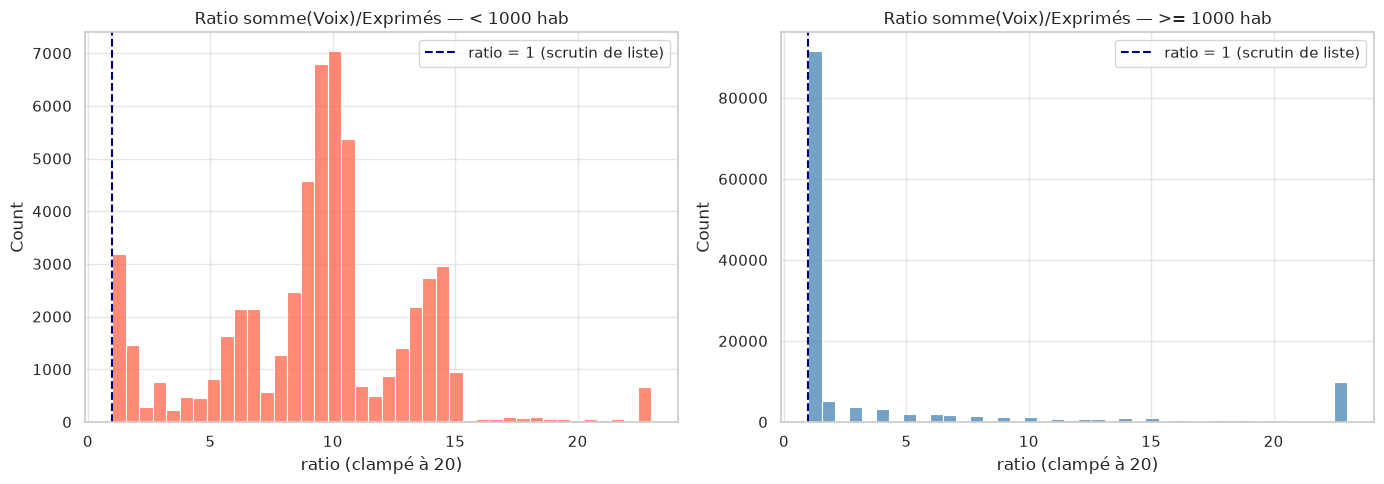

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, strate in zip(axes, ['< 1000 hab', '>= 1000 hab']):
    data = check_bv.loc[check_bv['strate'] == strate, 'ratio_panachage'].clip(upper=23)
    sns.histplot(data, bins=40, ax=ax, color='tomato' if strate == '< 1000 hab' else 'steelblue')
    ax.axvline(1, color='navy', linestyle='--', label='ratio = 1 (scrutin de liste)')
    ax.set_title(f"Ratio somme(Voix)/Exprimés — {strate}")
    ax.set_xlabel("ratio (clampé à 20)")
    ax.legend()

plt.tight_layout()
plt.show()

**Lecture attendue du graphique :**
- À droite (≥1000 hab), le ratio devrait être concentré près d'une valeur entière faible
  (nombre de listes), avec une distribution propre.
- À gauche (<1000 hab), le ratio devrait être étalé et corrélé au nombre de sièges
  (donc à la population), ce qui **confirme que ce n'est pas un bruit aléatoire**
  mais un effet déterministe du mode de scrutin.

On vérifie cette corrélation directement :


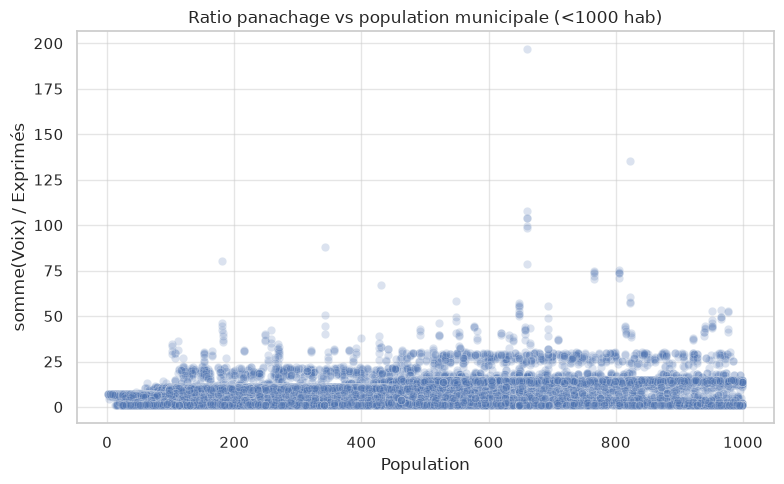

                 population  ratio_panachage
population         1.000000         0.435859
ratio_panachage    0.435859         1.000000


In [40]:
sub = check_bv[check_bv['strate'] == '< 1000 hab'].copy()
sub['ratio_arrondi'] = sub['ratio_panachage'].round()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sub, x='population', y='ratio_panachage', alpha=0.2, ax=ax)
ax.set_title("Ratio panachage vs population municipale (<1000 hab)")
ax.set_xlabel("Population")
ax.set_ylabel("somme(Voix) / Exprimés")
plt.tight_layout()
plt.show()

print(sub[['population', 'ratio_panachage']].corr())

### 5.1 Séparer panachage et vraies anomalies

Pour les communes **< 1000 hab**, un ratio non-entier ou très instable (ex. 2.37, 0.85)
est suspect — le panachage produit en théorie un ratio proche d'un entier (le nombre
de sièges, sous réserve que tous les électeurs utilisent tous leurs bulletins, donc
en pratique légèrement inférieur). Un ratio **inférieur à 1** est en revanche
**anormal dans tous les cas** (même en panachage, sum(Voix) ne peut pas être inférieur
aux exprimés sauf erreur de saisie ou bureau où personne n'a voté pour plusieurs candidats).


In [41]:
# Seuils de diagnostic, à ajuster selon vos données réelles après premier passage
sub_1000 = check_bv[check_bv['strate'] == '< 1000 hab'].copy()

anomalie_sous_1 = sub_1000['ratio_panachage'] < 0.98          # vraie anomalie : impossible
panachage_normal = sub_1000['ratio_panachage'].between(0.98, 20)  # plausible si <= nb sièges max légal (23)
anomalie_extreme = sub_1000['ratio_panachage'] > 23            # au-delà du max légal de sièges -> anomalie

print(f"Bureaux <1000 hab avec ratio < 0.98 (anomalie)         : {anomalie_sous_1.sum():,}")
print(f"Bureaux <1000 hab avec ratio plausible (panachage)     : {panachage_normal.sum():,}")
print(f"Bureaux <1000 hab avec ratio > 23 (anomalie extrême)   : {anomalie_extreme.sum():,}")

display(sub_1000[anomalie_sous_1 | anomalie_extreme].head(15))

Bureaux <1000 hab avec ratio < 0.98 (anomalie)         : 0
Bureaux <1000 hab avec ratio plausible (panachage)     : 54,479
Bureaux <1000 hab avec ratio > 23 (anomalie extrême)   : 658


,Annee,Tour,Code département,Code commune,ID Bureau de vote,strate,geo_nom,somme_voix,exprimes,population,n_candidats,ratio_panachage
34601,2014,1,01,184,1,< 1000 hab,Hautecourt-Romanèche,3406.0,132,748.0,17,25.803030
34602,2014,1,01,184,2,< 1000 hab,Hautecourt-Romanèche,1442.0,52,748.0,17,27.730769
34679,2014,1,01,245,1,< 1000 hab,Bohas-Meyriat-Rignat,2386.0,58,938.0,24,41.137931
34680,2014,1,01,245,2,< 1000 hab,Bohas-Meyriat-Rignat,1949.0,47,938.0,24,41.468085
34681,2014,1,01,245,3,< 1000 hab,Bohas-Meyriat-Rignat,2240.0,57,938.0,24,39.298246
35003,2014,1,01,58,1,< 1000 hab,Brégnier-Cordon,3769.0,150,804.0,22,25.126667
35004,2014,1,01,58,2,< 1000 hab,Brégnier-Cordon,1552.0,65,804.0,22,23.876923
35307,2014,1,02,308,1,< 1000 hab,Fesmy-le-Sart,2163.0,88,519.0,16,24.579545
35308,2014,1,02,308,2,< 1000 hab,Fesmy-le-Sart,1062.0,40,519.0,16,26.550000
35339,2014,1,02,336,1,< 1000 hab,Frières-Faillouël,3712.0,153,971.0,16,24.261438


**Note méthodologique importante :** contrairement à l'approche du notebook 2
(`facteur = ecart_relatif + 1` appliqué pour "corriger" `Exprimés`), on **ne modifie pas**
`Exprimés`/`Inscrits`/`Votants` pour les bureaux en panachage normal — ces valeurs sont
correctes telles que saisies, c'est l'**interprétation du ratio de voix** qui doit changer.
Multiplier les agrégats par le ratio reviendrait à inventer des inscrits/votants
fictifs. On ne corrige que les vraies anomalies (`ratio < 0.98` ou `> 23` sièges max),
typiquement par suppression ou contrôle manuel ciblé, jamais par un facteur global.


In [42]:
# Exemple de traitement des vraies anomalies (à valider au cas par cas avant suppression
# en production — ici on illustre la marche à suivre)
bureaux_anormaux = sub_1000.loc[anomalie_sous_1 | anomalie_extreme, bv_keys]

print(f"{len(bureaux_anormaux)} bureaux de vote à examiner / exclure des analyses agrégées.")
df['bureau_anormal'] = df.set_index(bv_keys).index.isin(
    bureaux_anormaux.set_index(bv_keys).index
)
print(df['bureau_anormal'].value_counts())

658 bureaux de vote à examiner / exclure des analyses agrégées.
bureau_anormal
False    1569479
True       14772
Name: count, dtype: int64


## 6. Recalcul des indicateurs — séparés par strate

Les taux qui se calculent sans ambiguïté dans **les deux régimes** (car ils ne
dépendent pas du panachage) :

- `taux_participation = Votants / Inscrits`
- `taux_abstention = Abstentions / Inscrits`
- `taux_vote_blanc_nul = (Votants - Exprimés) / Votants`

Les taux qui **ne sont comparables qu'au sein d'une même strate** (car le dénominateur
`Exprimés` n'a pas le même sens) :

- `pct_voix_exprimes = Voix / Exprimés` (par candidat) → en panachage, la somme sur
  tous les candidats d'un bureau ne fait pas 100 %, mais ≈ (nb sièges) × 100 %.
- Pour rendre ce taux comparable entre strates, on le **normalise par le nombre de
  sièges effectif du bureau** (estimé via le ratio de panachage) pour les communes <1000 hab.


In [43]:
df.describe()

,Annee,Tour,Inscrits,Votants,Abstentions,Exprimés,Voix,population,surface_km2,longitude,latitude,ID Bureau de vote,Vote Blanc
count,1.584251e+06,1.584251e+06,1.584251e+06,1.584251e+06,1.584251e+06,1.584251e+06,1.584251e+06,1.584251e+06,1.327126e+06,1.327126e+06,1.327126e+06,1.584251e+06,1.584251e+06
mean,2.017371e+03,1.168114e+00,5.159266e+02,2.977212e+02,2.182054e+02,2.879755e+02,1.349100e+02,7.167260e+04,2.713428e+03,2.755853e+00,4.699880e+01,2.009804e+01,9.745654e+00
std,5.008405e+00,3.739677e-01,4.051638e+02,2.184928e+02,2.247965e+02,2.126200e+02,1.085043e+02,3.023634e+05,4.118093e+03,2.559167e+00,2.241362e+00,7.953709e+01,1.270319e+01
min,2.008000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.840000e+00,-5.086900e+00,4.236020e+01,1.000000e+00,0.000000e+00
25%,2.014000e+03,1.000000e+00,1.640000e+02,1.170000e+02,3.900000e+01,1.130000e+02,5.200000e+01,3.310000e+02,7.586400e+02,1.040700e+00,4.507770e+01,1.000000e+00,2.000000e+00
50%,2.014000e+03,1.000000e+00,4.200000e+02,2.630000e+02,1.230000e+02,2.530000e+02,1.090000e+02,7.820000e+02,1.386730e+03,2.508300e+00,4.748570e+01,1.000000e+00,7.000000e+00
75%,2.020000e+03,1.000000e+00,8.380000e+02,4.400000e+02,3.670000e+02,4.260000e+02,1.960000e+02,1.002700e+04,2.918770e+03,4.842100e+00,4.885890e+01,7.000000e+00,1.300000e+01
max,2.026000e+03,2.000000e+00,1.114100e+04,2.161000e+03,1.056700e+04,2.054000e+03,1.449000e+03,2.103778e+06,7.567801e+04,8.193100e+00,5.107470e+01,9.030000e+02,6.880000e+02


In [44]:
df['taux_participation'] = np.where(
    df['Inscrits'] > 0,
    df['Votants'] / df['Inscrits'],
    0
)
df['taux_abstention'] = np.where(
    df['Inscrits'] > 0,
    df['Abstentions'] / df['Inscrits'],
    0
)
df['taux_vote_blanc_nul'] = np.where(
    df['Votants'] > 0,
    (df['Votants'] - df['Exprimés']) / df['Votants'],
    0
)
# Nombre de sièges effectif estimé par bureau (panachage) -> 1 pour les communes >= 1000 hab
nb_sieges_estime = check_bv.set_index(bv_keys)['ratio_panachage'].round().clip(lower=1)
df = df.join(nb_sieges_estime.rename('nb_sieges_estime'), on=bv_keys)
df.loc[df['strate'] == '>= 1000 hab', 'nb_sieges_estime'] = 1

# pct_voix_exprimes "brut" (non comparable entre strates) vs "normalisé" (comparable)
df['pct_voix_exprimes_brut'] = np.where(
    df['Exprimés'] > 0,
    df['Voix'] / df['Exprimés'],
    0
)
df['pct_voix_exprimes_normalise'] = np.where(
    df['nb_sieges_estime'] > 0,
    df['pct_voix_exprimes_brut'] / df['nb_sieges_estime'],
    0
)
df[['strate', 'nb_sieges_estime', 'pct_voix_exprimes_brut', 'pct_voix_exprimes_normalise']].groupby('strate').describe().T

strate                                < 1000 hab    >= 1000 hab
nb_sieges_estime            count  793854.000000  622335.000000
                            mean       10.729754       1.000000
                            std         5.100440       0.000000
                            min         1.000000       1.000000
                            25%         9.000000       1.000000
                            50%        10.000000       1.000000
                            75%        13.000000       1.000000
                            max       197.000000       1.000000
pct_voix_exprimes_brut      count  961916.000000  622335.000000
                            mean        0.628653       5.372731
                            std         0.343589      28.909028
                            min         0.000000       0.000000
                            25%         0.412821       0.133114
                            50%         0.647826       0.403727
                            75%         0.881720       1.044444
                            max        12.500000     754.000000
pct_voix_exprimes_normalise count  961916.000000  622335.000000
                            mean        0.057387       5.372731
                            std         0.060256      28.909028
                            min         0.000000       0.000000
                            25%         0.022133       0.133114
                            50%         0.056566       0.403727
                            75%         0.086168       1.044444
                            max         1.040000     754.000000

## 7. EDA comparative — l'homogénéité retrouvée

On reproduit les graphiques classiques du notebook 2 (distribution, évolution
temporelle), mais **systématiquement scindés par strate**, pour vérifier que
chaque sous-population est désormais statistiquement homogène en interne.


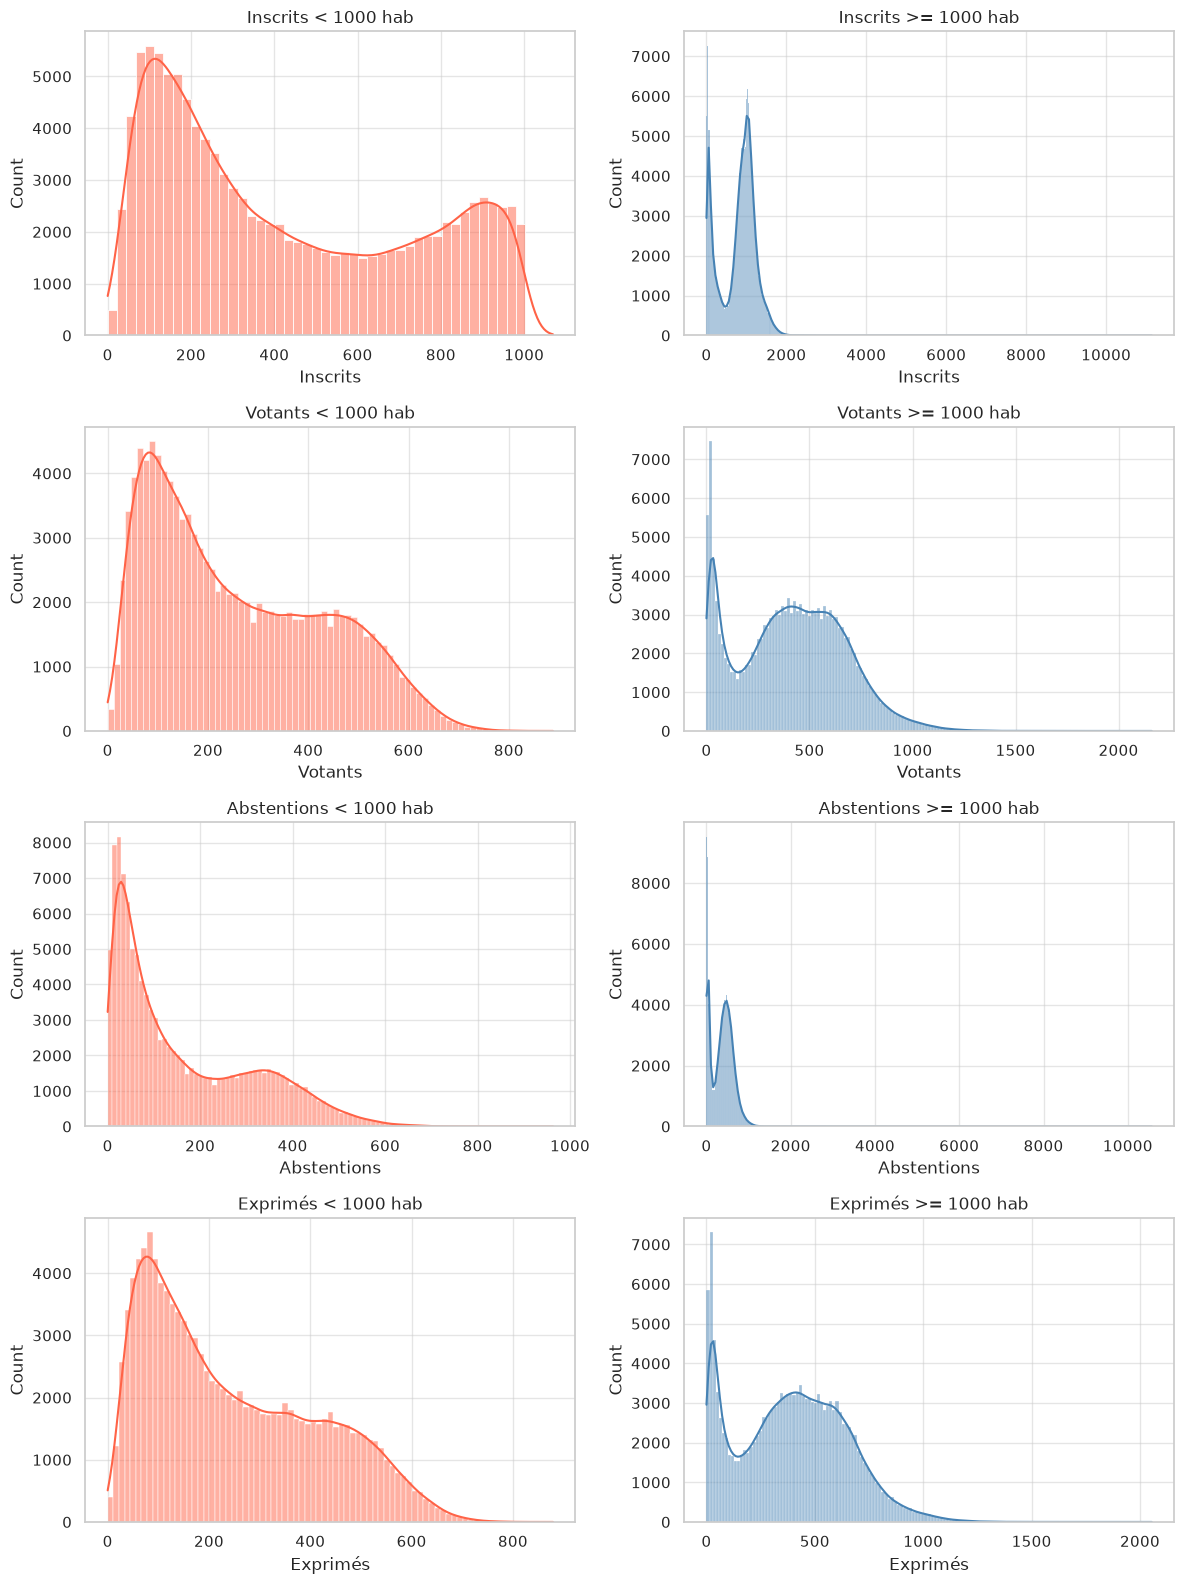

In [45]:
quant_cols = ['Inscrits', 'Votants', 'Abstentions', 'Exprimés']

bv_level = df.drop_duplicates(bv_keys)

fig, axes = plt.subplots(len(quant_cols), 2, figsize=(12, 4 * len(quant_cols)))
for i, col in enumerate(quant_cols):
    for j, strate in enumerate(['< 1000 hab', '>= 1000 hab']):
        ax = axes[i, j]
        data = bv_level.loc[bv_level['strate'] == strate, col]
        sns.histplot(data, ax=ax, kde=True, color='tomato' if strate == '< 1000 hab' else 'steelblue')
        ax.set_title(f"{col} {strate}")
plt.tight_layout()
plt.show()

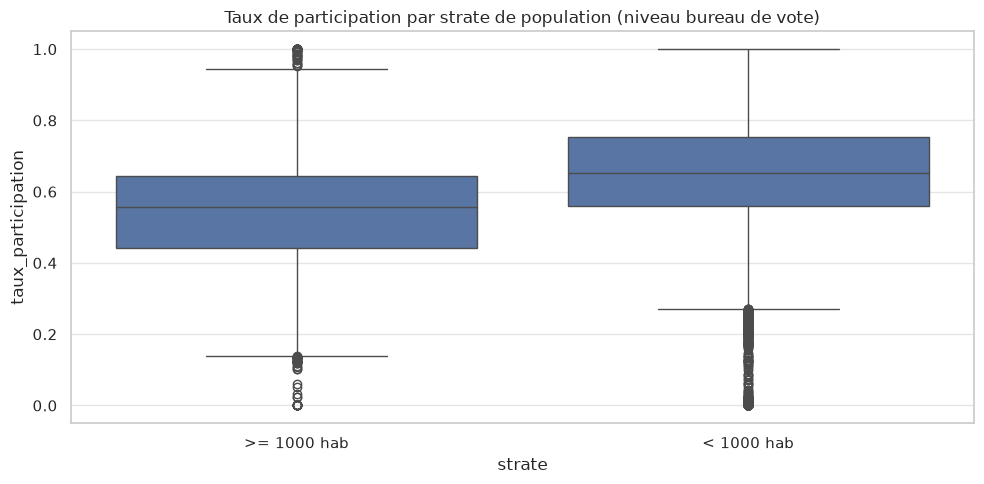

                count      mean       std  min       25%       50%       75%  max
strate                                                                           
< 1000 hab   117586.0  0.654268  0.137153  0.0  0.560000  0.652681  0.753149  1.0
>= 1000 hab  156496.0  0.541563  0.135242  0.0  0.440797  0.558248  0.642857  1.0


In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=bv_level, x='strate', y='taux_participation', ax=ax)
ax.set_title("Taux de participation par strate de population (niveau bureau de vote)")
plt.tight_layout()
plt.show()

print(bv_level.groupby('strate')['taux_participation'].describe())

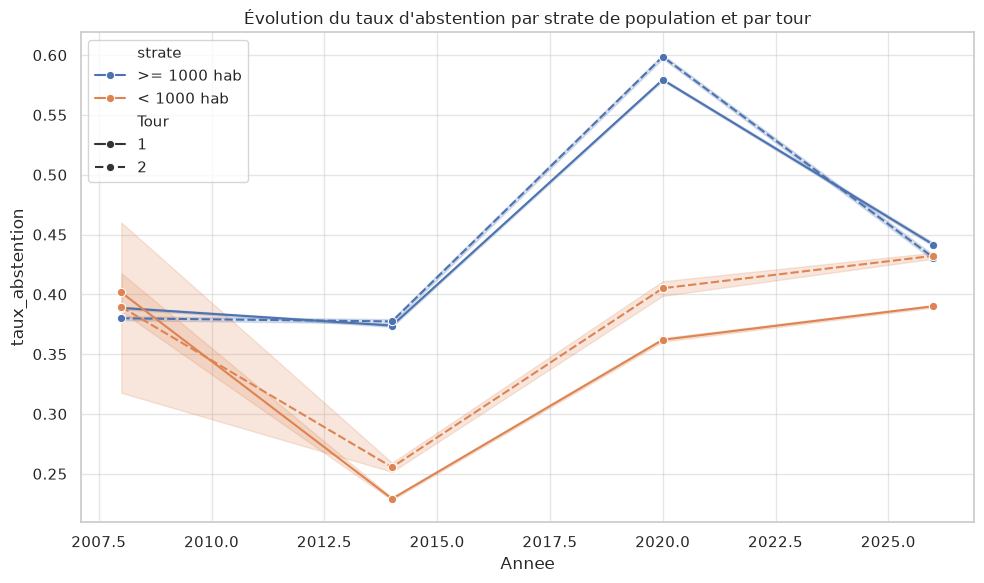

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=bv_level, x='Annee', y='taux_abstention', hue='strate', style='Tour', marker='o', ax=ax)
ax.set_title("Évolution du taux d'abstention par strate de population et par tour")
plt.tight_layout()
plt.show()

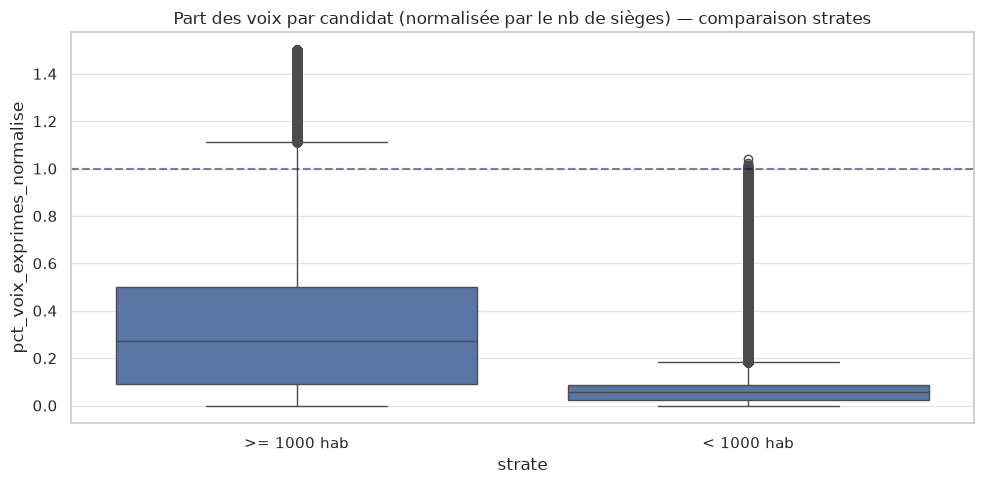

In [48]:
# Vérification que pct_voix_exprimes_normalise est désormais comparable entre strates
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df[df['pct_voix_exprimes_normalise'].between(0, 1.5)],  # on retire les cas extrêmes restants
    x='strate', y='pct_voix_exprimes_normalise', ax=ax
)
ax.set_title("Part des voix par candidat (normalisée par le nb de sièges) — comparaison strates")
ax.axhline(1, color='navy', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [49]:
# Variance des taux par strate : la métrique qui répond directement à
# "mes stats ne sont plus homogènes" -> on quantifie l'hétérogénéité avant/après
metrics = ['taux_participation', 'taux_abstention', 'pct_voix_exprimes_brut', 'pct_voix_exprimes_normalise']

summary = bv_level.groupby('strate')[['taux_participation', 'taux_abstention']].agg(['mean', 'std', 'var'])
print("Dispersion des taux indépendants du panachage (déjà comparables) :")
display(summary)

summary2 = df.groupby('strate')[['pct_voix_exprimes_brut', 'pct_voix_exprimes_normalise']].agg(['mean', 'std', 'var'])
print("\nDispersion de pct_voix_exprimes BRUT vs NORMALISÉ :")
display(summary2)

Dispersion des taux indépendants du panachage (déjà comparables) :


taux_participation                     taux_abstention                    
                          mean       std       var            mean       std       var
strate                                                                                
< 1000 hab            0.654268  0.137153  0.018811        0.345587  0.136990  0.018766
>= 1000 hab           0.541563  0.135242  0.018290        0.458411  0.135234  0.018288


Dispersion de pct_voix_exprimes BRUT vs NORMALISÉ :


pct_voix_exprimes_brut                        pct_voix_exprimes_normalise                       
                              mean        std         var                        mean        std         var
strate                                                                                                      
< 1000 hab                0.628653   0.343589    0.118054                    0.057387   0.060256    0.003631
>= 1000 hab               5.372731  28.909028  835.731902                    5.372731  28.909028  835.731902

**Lecture attendue :** la variance de `pct_voix_exprimes_brut` doit être nettement
plus élevée pour `< 1000 hab` que pour `>= 1000 hab` (c'est exactement
l'hétérogénéité que vous observez). Après normalisation par le nombre de sièges
estimé, la variance des deux strates doit se rapprocher — c'est la preuve que
l'hétérogénéité venait bien du panachage et non d'un autre phénomène caché.


In [50]:
# Test de Levene (homogénéité des variances) pour objectiver le diagnostic
from scipy.stats import levene

g1 = df.loc[df['strate'] == '< 1000 hab', 'pct_voix_exprimes_brut'].dropna()
g2 = df.loc[df['strate'] == '>= 1000 hab', 'pct_voix_exprimes_brut'].dropna()
stat, p = levene(g1, g2)
print(f"Levene (brut)       : stat={stat:.2f}, p-value={p:.4g}")

g1n = df.loc[df['strate'] == '< 1000 hab', 'pct_voix_exprimes_normalise'].dropna()
g2n = df.loc[df['strate'] == '>= 1000 hab', 'pct_voix_exprimes_normalise'].dropna()
stat_n, p_n = levene(g1n, g2n)
print(f"Levene (normalisé)  : stat={stat_n:.2f}, p-value={p_n:.4g}")

Levene (brut)       : stat=28323.96, p-value=0
Levene (normalisé)  : stat=30955.90, p-value=0


In [27]:
df.to_csv("../../data/processed/Analysis_Municipale.csv", index=False, sep=";")